# Food Delivery Data Visualization Portfolio



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("Day14_Food_Delivery_Visualization_Dataset.csv")

df.head()

,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [2]:
print("Shape of dataset:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

df["Date"] = pd.to_datetime(df["Date"])

df.info()

Shape of dataset: (360, 16)

Columns:
['Order_Batch_ID', 'Date', 'Month', 'Day', 'City', 'Cuisine', 'Order_Channel', 'Weather', 'Orders', 'Average_Order_Value', 'Revenue', 'Marketing_Spend', 'Discounts', 'Avg_Delivery_Minutes', 'Customer_Rating', 'Repeat_Customer_Percent']

Missing values:
Order_Batch_ID             0
Date                       0
Month                      0
Day                        0
City                       0
Cuisine                    0
Order_Channel              0
Weather                    0
Orders                     0
Average_Order_Value        0
Revenue                    0
Marketing_Spend            0
Discounts                  0
Avg_Delivery_Minutes       0
Customer_Rating            0
Repeat_Customer_Percent    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   

## Orders over the Months

A line plot is useful here because I want to see how the average number of orders changes from month to month.

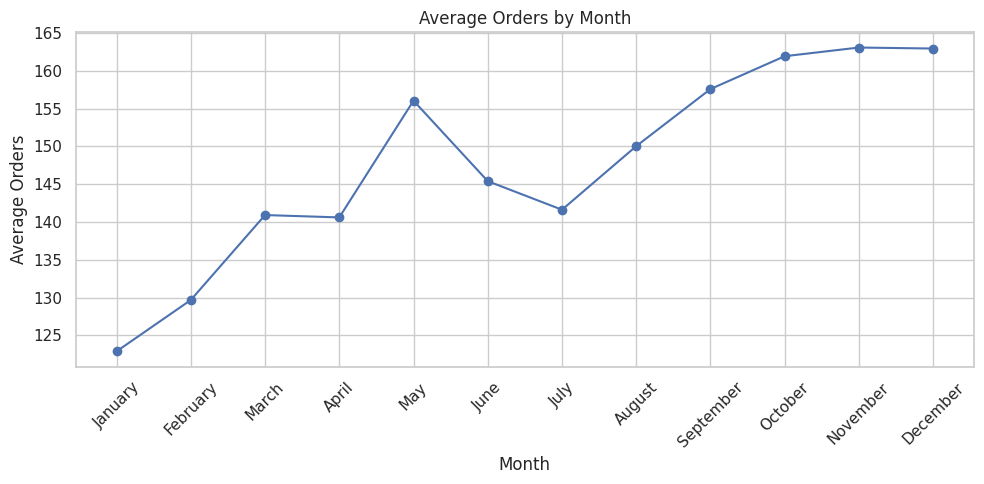

In [3]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_orders = df.groupby("Month")["Orders"].mean().reindex(month_order)

plt.figure(figsize=(10, 5))
plt.plot(monthly_orders.index, monthly_orders.values, marker="o")
plt.title("Average Orders by Month")
plt.xlabel("Month")
plt.ylabel("Average Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** Average orders are lowest in January and gradually become stronger later in the year. November and December have the highest average order volume, suggesting stronger demand towards the end of the year.

## Revenue over the Months

I used another line plot to see whether the revenue trend follows the order trend.

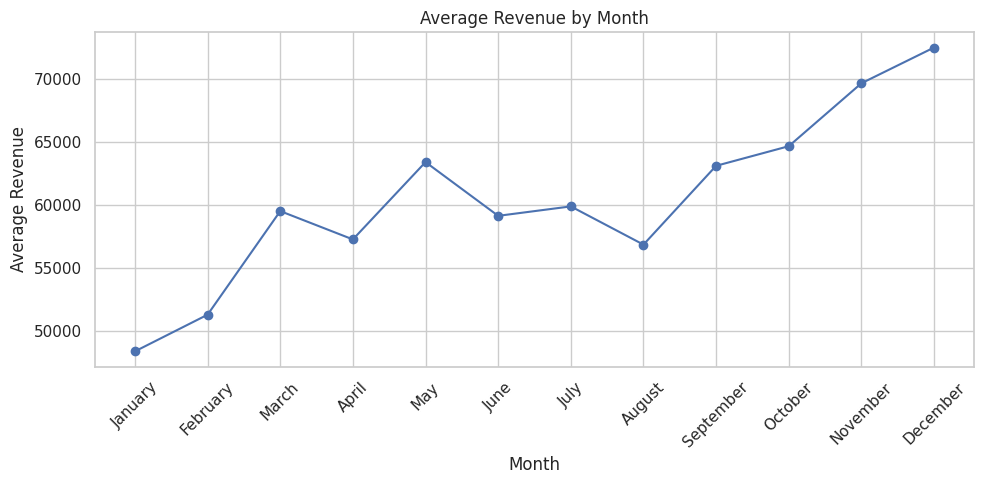

In [4]:
monthly_revenue = df.groupby("Month")["Revenue"].mean().reindex(month_order)

plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")
plt.title("Average Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** Revenue follows a similar pattern to orders, with December showing the highest average revenue and January the lowest. This suggests that the increase in order volume towards the end of the year is also reflected in revenue.

## Average Revenue by City



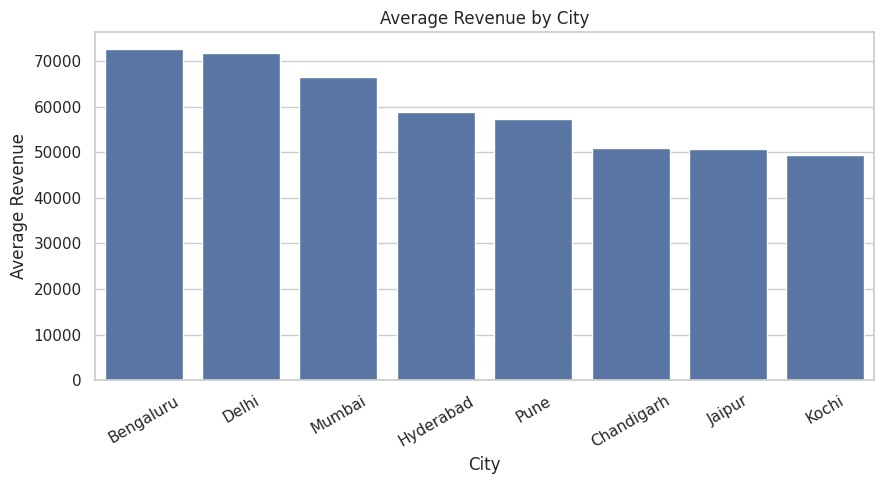

In [5]:
city_revenue = df.groupby("City")["Revenue"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=city_revenue.index, y=city_revenue.values)
plt.title("Average Revenue by City")
plt.xlabel("City")
plt.ylabel("Average Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Interpretation:** Bengaluru and Delhi have the highest average revenue in the dataset. Kochi and Jaipur are at the lower end, showing that revenue performance varies considerably between cities.

## Average Revenue by Cuisine



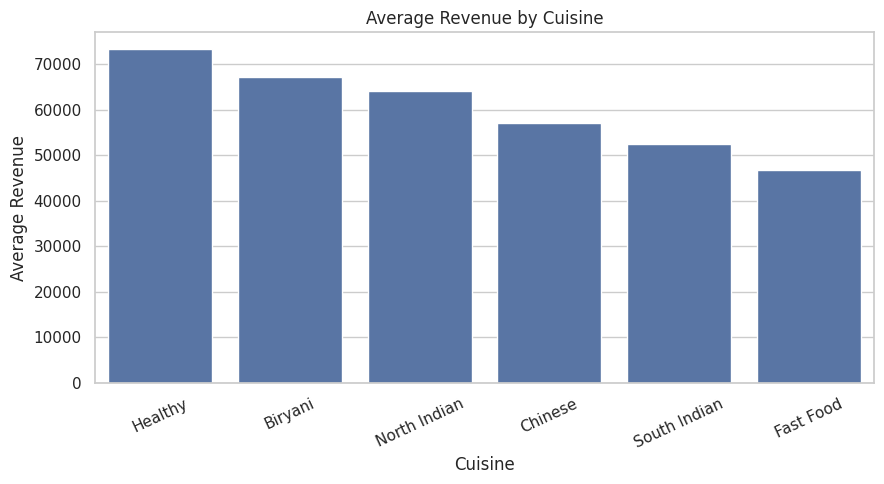

In [6]:
cuisine_revenue = df.groupby("Cuisine")["Revenue"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=cuisine_revenue.index, y=cuisine_revenue.values)
plt.title("Average Revenue by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Average Revenue")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

**Interpretation:** Healthy and Biryani have the highest average revenue, while Fast Food has the lowest average revenue among the cuisines. This difference could be useful when planning promotions or understanding customer demand.

## Distribution of Orders



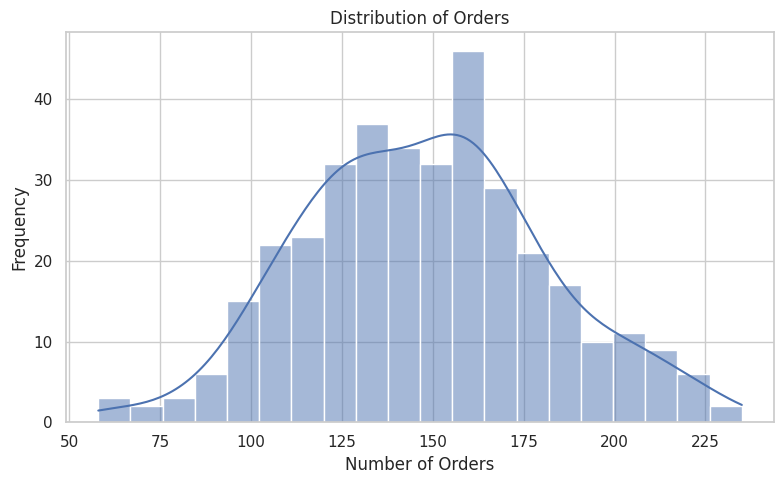

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Orders"], bins=20, kde=True)
plt.title("Distribution of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Interpretation:** Most observations are concentrated around the middle range of order volumes. Very low and very high order counts occur less often, so the dataset mostly represents moderate order activity.

## Marketing Spend vs Revenue



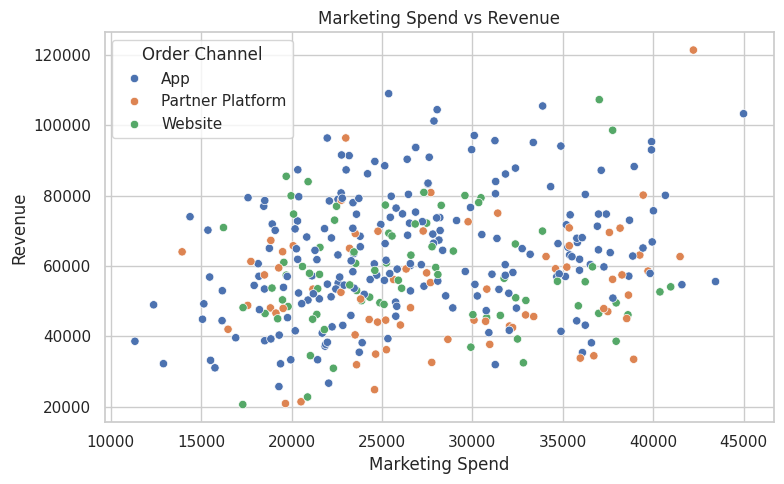

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Marketing_Spend", y="Revenue", hue="Order_Channel")
plt.title("Marketing Spend vs Revenue")
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")
plt.legend(title="Order Channel")
plt.tight_layout()
plt.show()

**Interpretation:** The plot shows a positive relationship between marketing spend and revenue, although the points are spread out. This means marketing spend may contribute to higher revenue, but it is clearly not the only factor involved.

## Delivery Time and Customer Rating

I used a scatter plot to see whether delivery time is related to customer ratings. Weather is added using `hue` to see if the pattern changes under different conditions.

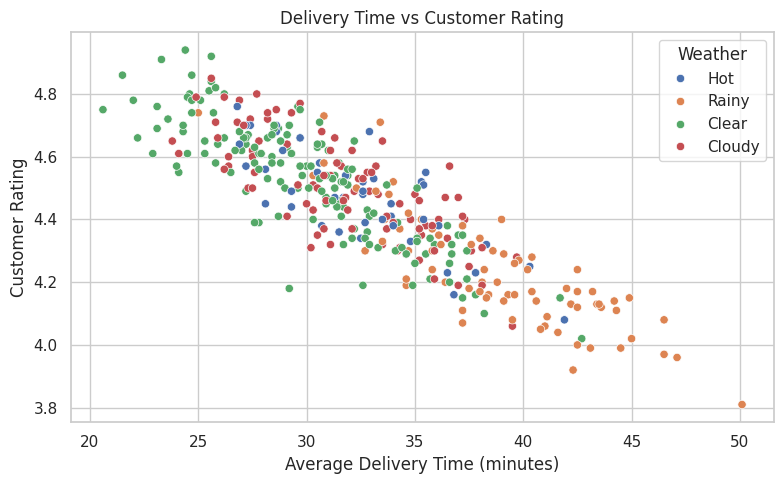

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Avg_Delivery_Minutes", y="Customer_Rating", hue="Weather")
plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Average Delivery Time (minutes)")
plt.ylabel("Customer Rating")
plt.legend(title="Weather")
plt.tight_layout()
plt.show()

**Interpretation:** Ratings generally tend to be lower when delivery takes longer. Rainy weather is especially noticeable because it has both longer delivery times and lower average customer ratings.

## Revenue Distribution by Weather



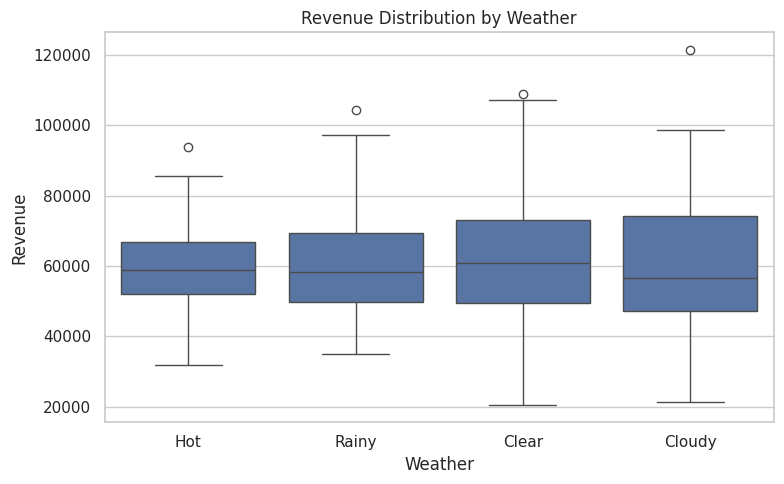

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Weather", y="Revenue")
plt.title("Revenue Distribution by Weather")
plt.xlabel("Weather")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

**Interpretation:** Revenue has a fairly wide spread under all weather conditions. The distributions are broadly similar, so weather appears to have a more noticeable effect on delivery experience than on revenue itself.

##  Delivery Time by Order Channel


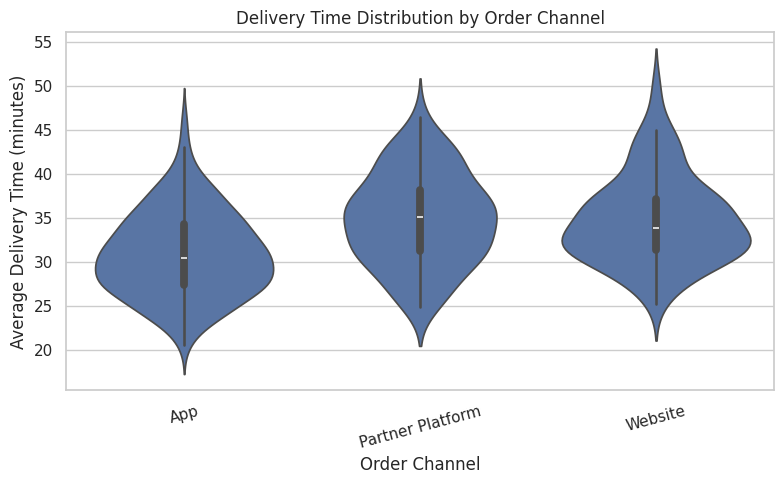

In [11]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="Order_Channel", y="Avg_Delivery_Minutes")
plt.title("Delivery Time Distribution by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Interpretation:** App orders generally have lower delivery times than Website and Partner Platform orders. The violin shapes also show that delivery time varies within each channel rather than staying at one fixed value.

## Order Channel across Weather Conditions



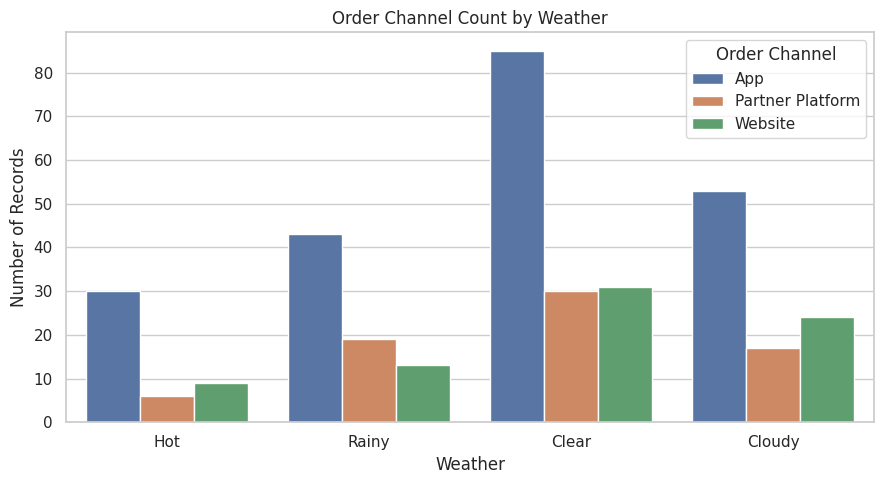

In [12]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="Weather", hue="Order_Channel")
plt.title("Order Channel Count by Weather")
plt.xlabel("Weather")
plt.ylabel("Number of Records")
plt.legend(title="Order Channel")
plt.tight_layout()
plt.show()

**Interpretation:** The count plot shows the distribution of the three order channels across different weather conditions. App orders form a large part of the observations across the weather categories, while Partner Platform and Website orders are also consistently present.

## Correlation Heatmap



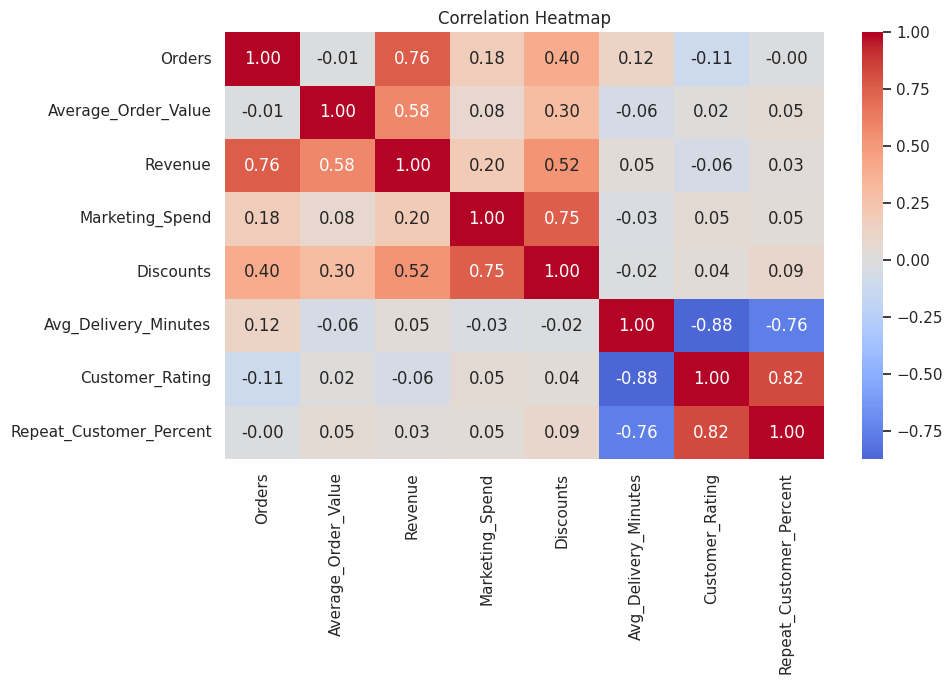

In [13]:
numeric_data = df.select_dtypes(include="number")

correlation = numeric_data.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Interpretation:** Revenue has its strongest positive relationship with Orders, followed by Average Order Value. Discounts also have a noticeable positive correlation with revenue, while Marketing Spend has a weaker positive relationship. Customer Rating and Repeat Customer Percentage have very little linear correlation with revenue in this dataset.

# Final Summary

The visualizations helped highlight several useful patterns in the food delivery data:

- **Orders and revenue are strongest towards the end of the year**, especially in November and December.
- **Bengaluru and Delhi** have the highest average revenue among the cities.
- **Healthy and Biryani** have the highest average revenue among the cuisines.
- **Marketing spend and revenue show a positive relationship**, but marketing spend alone does not explain revenue.
- **Longer delivery times are generally associated with lower customer ratings.**
- **Rainy weather** stands out for longer delivery times and lower customer ratings.
- The correlation heatmap shows that **Orders have the strongest numerical relationship with Revenue**, followed by Average Order Value.

